In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import load_iris

# Load dataset Iris tanpa internet
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


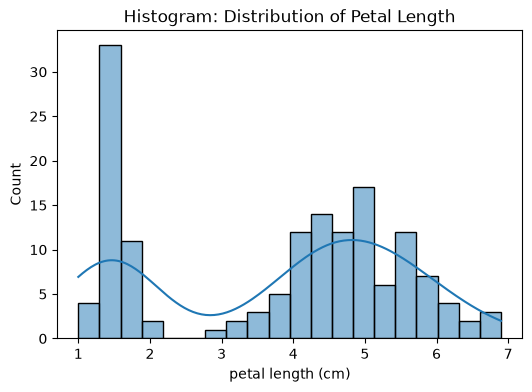

In [8]:
# 1. Histogram
plt.figure(figsize=(6, 4))

sns.histplot(
    df["petal length (cm)"],
    bins=20,
    kde=True
)

plt.title("Histogram: Distribution of Petal Length")
plt.show()

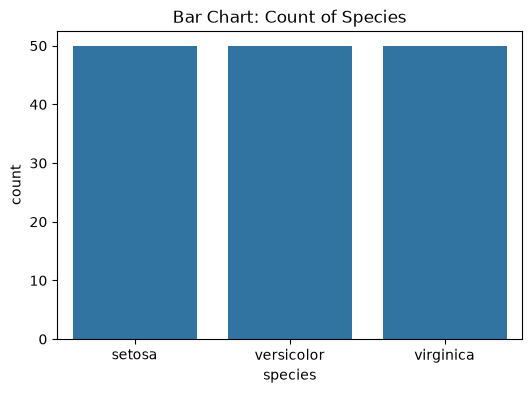

In [9]:
# 2. Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(x="species", data=df)
plt.title("Bar Chart: Count of Species")
plt.show()

In [13]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset dari sklearn
iris = load_iris(as_frame=True)
df = iris.frame


In [14]:
# 3. Box Plot
plt.figure(figsize=(6, 4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Box Plot: Petal Length by Species")
plt.show()

ValueError: Could not interpret value `species` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [15]:
# 4. Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()

ValueError: Could not interpret value `sepal_length` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [ ]:
# 5. Pair Plot
sns.pairplot(df, hue="species")
plt.suptitle("Pair Plot: Feature Relationships", y=1.02)
plt.show()

In [ ]:
# 6. Line Plot
plt.figure(figsize=(6, 4))
df["random_growth"] = np.random.randn(len(df)).cumsum()
sns.lineplot(x=df.index, y="random_growth", data=df)
plt.title("Line Plot: Simulated Growth Over Index")
plt.show()

In [ ]:
# 7. Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap: Feature Correlation")
plt.show()

In [ ]:
# 8. 3D Scatter Plot
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
species = df["species"].unique()
colors = ["r", "g", "b"]

for sp, col in zip(species, colors):
    subset = df[df["species"] == sp]
    ax.scatter(subset["sepal_length"], subset["sepal_width"], subset["petal_length"], c=col, label=sp, s=50)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("3D Scatter Plot: Sepal Length, Sepal Width, Petal Length")
ax.legend()
plt.show()

In [ ]:
# 9. Model-Specific Visualization (e.g Modeling using Random Forest)
# Split data
X = df.drop("species", axis=1)
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 9.1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# 9.2. ROC-AUC Curve (multi-class with One-vs-Rest)
# Binarize Labels
y_bin = label_binarize(y, classes=model.classes_)
n_classes = y_bin.shape[1]

# Train OvR classifier
ovr_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovr_model.fit(X_train, label_binarize(y_train, classes=model.classes_))
y_score = ovr_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=model.classes_)

# Plot ROC curve
plt.figure(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--") # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
# 9.3. Feature Importance Plot
X = df.drop("species", axis=1)
y = df["species"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()